In [1]:
# General imports
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))
colors = sns.color_palette("Paired")
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/s2265800/miniforge3/envs/mgl_ccl_cloe_mgjax_env/lib/python3.11/site-packages/HMcode2020Emu
Loading linear emulator...


Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## Cosmology: Background and Perturbations for binned DE

* change expansion: $$ \frac{H^2(z)}{H_0^2} = \Omega_{\rm m} (1+z)^3 + (1-\Omega_{\rm m}) f_{\rm DE}(z)$$ with $$f_{\rm DE}(z) = \left( \frac{1+z}{1+z_j-\Delta z_j/2} \right)^{3(1+w_j)} \Pi^{j-1}_{i=1} \left( \frac{1+z_i+\Delta z_i/2}{1+z_i-\Delta z_i/2}\right)^{3(1+w_i)}$$ or $$f(z) = f_i\,\,\,\mathrm{for } \,\,\,z_i-\Delta z_i/2<z<z_i+\Delta z_i$$
* change distances: $r_{\rm com}(z)=\int_0^{z} \frac{c \mathrm{d}z'}{H(z')}$
* change linear growth: JaxMGrowth

In [2]:
w0=-0.7 
wa=-1.2 

In [3]:
zs = np.logspace(-3, 2, 64)
zfinal = 100.
zmax = 3.
zmin = 0.
zbin_edges = np.array([0., 0.4, 0.8, 1.2, 1.6, 2., zmax, zfinal])
zbin_centers = 0.5*(zbin_edges[1:] + zbin_edges[:-1])
zbin_widths = np.diff(zbin_edges)
w_i = np.array([w0+wa*(zbin_centers[i]/(1.+zbin_centers[i])) for i in range(len(zbin_centers))])
Nbin = len(zbin_centers)
print('w_i: ', w_i)
print('z-bin edges: ', zbin_edges)
print('z-bin centers: ', zbin_centers)
print('z-bin widths: ', zbin_widths)
print('Nbin: ', Nbin, len(w_i))

w_i:  [-0.9        -1.15       -1.3        -1.4        -1.47142857 -1.55714286
 -1.87714286]
z-bin edges:  [  0.    0.4   0.8   1.2   1.6   2.    3.  100. ]
z-bin centers:  [ 0.2  0.6  1.   1.4  1.8  2.5 51.5]
z-bin widths:  [ 0.4  0.4  0.4  0.4  0.4  1.  97. ]
Nbin:  7 7


In [4]:
Nz_fine = 30
zbin_fine_widths = np.hstack(((zmax-zmin)/Nz_fine*np.ones(Nz_fine), [(zfinal-zmax)]))
zbin_fine_edges = np.concatenate(([0.], np.cumsum(zbin_fine_widths)))
zbin_fine_centers = 0.5*(zbin_fine_edges[1:] + zbin_fine_edges[:-1])
w_i_fine = np.array([w0+wa*(zbin_fine_centers[i]/(1.+zbin_fine_centers[i])) for i in range(len(zbin_fine_centers))])
Nbin_fine = len(zbin_fine_centers)
print('w_i_fine: ', w_i_fine)
print('z-bin edges: ', zbin_fine_edges)
print('z-bin centers: ', zbin_fine_centers)
print('z-bin widths: ', zbin_fine_widths)
print('Nbin_fine: ', Nbin_fine, len(w_i_fine))

w_i_fine:  [-0.75714286 -0.85652174 -0.94       -1.01111111 -1.07241379 -1.12580645
 -1.17272727 -1.21428571 -1.25135135 -1.28461538 -1.31463415 -1.34186047
 -1.36666667 -1.3893617  -1.41020408 -1.42941176 -1.44716981 -1.46363636
 -1.47894737 -1.49322034 -1.50655738 -1.51904762 -1.53076923 -1.54179104
 -1.55217391 -1.56197183 -1.57123288 -1.58       -1.58831169 -1.59620253
 -1.87714286]
z-bin edges:  [  0.    0.1   0.2   0.3   0.4   0.5   0.6   0.7   0.8   0.9   1.    1.1
   1.2   1.3   1.4   1.5   1.6   1.7   1.8   1.9   2.    2.1   2.2   2.3
   2.4   2.5   2.6   2.7   2.8   2.9   3.  100. ]
z-bin centers:  [5.00e-02 1.50e-01 2.50e-01 3.50e-01 4.50e-01 5.50e-01 6.50e-01 7.50e-01
 8.50e-01 9.50e-01 1.05e+00 1.15e+00 1.25e+00 1.35e+00 1.45e+00 1.55e+00
 1.65e+00 1.75e+00 1.85e+00 1.95e+00 2.05e+00 2.15e+00 2.25e+00 2.35e+00
 2.45e+00 2.55e+00 2.65e+00 2.75e+00 2.85e+00 2.95e+00 5.15e+01]
z-bin widths:  [ 0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1
  0.1  0.1  0.

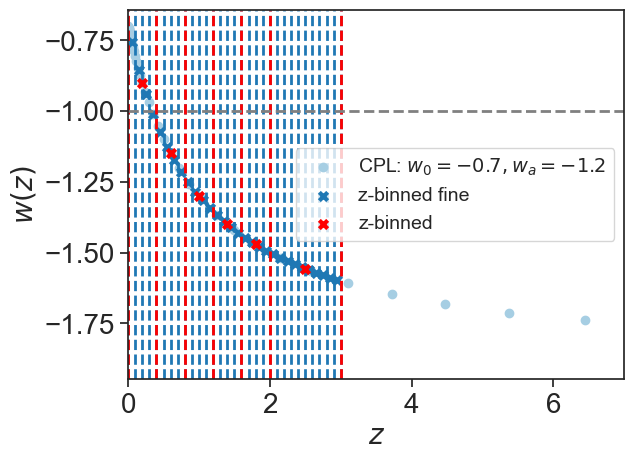

In [37]:
# plot w(z) from the three scenarios
plt.scatter(zs, w0+wa*(zs/(1.+zs)), label=f'CPL: $w_0={w0}, w_a={wa}$')
plt.scatter(zbin_fine_centers, w_i_fine, marker='x', label='z-binned fine')
plt.scatter(zbin_centers, w_i, label='z-binned', color='red', marker='x', zorder=10)
for i in range(len(zbin_fine_edges)):
    plt.axvline(x=zbin_fine_edges[i], c=colors[1], ls='--', lw=2)
for i in range(len(zbin_edges)):
    plt.axvline(x=zbin_edges[i], c='red', ls='--', lw=2)    
#plt.xscale('log')
plt.axhline(y=-1, c='grey', ls='--', lw=2)
plt.xlabel('$z$')
plt.ylabel('$w(z)$')
plt.xlim(0, 7.)
plt.legend()
plt.show()


In [6]:
# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=w0, 
                            wa=wa, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.0,
                            gamma_MG = 0.545)
Omega_m = 0.25+0.05
H0 = 70.

In [7]:
hubble_cpl = background.hubble_parameter(zs, units="km/s/Mpc")
rcom_cpl = background.comoving_distance(zs)

In [8]:
def get_z_bin_jax(z, zbin_edges):
    """
    Returns the bin index for a given redshift value.
    JAX-compatible version.
    
    Parameters:
    -----------
    z : float or array-like
        Redshift value(s) to bin
    zbin_edges : array-like
        Array of bin edges (must be sorted in ascending order)
    
    Returns:
    --------
    bin_index : int or array
        Bin index (0-indexed). Returns -1 for values below the first edge
        and len(zbin_edges)-2 for values at or above the last edge.
    """
    # Convert to JAX arrays for JAX compatibility
    z = jnp.asarray(z)
    zbin_edges = jnp.asarray(zbin_edges)
    
    # jnp.searchsorted is JAX-compatible equivalent of np.digitize
    # side='right' with z < zbin_edges gives left-inclusive behavior
    # We subtract 1 to get 0-indexed bins
    bin_idx = jnp.searchsorted(zbin_edges, z, side='right') - 1
    
    # Handle edge cases:
    # - Values below first edge get -1
    # - Values at or above last edge get the last bin index
    bin_idx = jnp.clip(bin_idx, -1, len(zbin_edges) - 2)
    
    # For values exactly at or above the last edge, put them in the last bin
    bin_idx = jnp.where(z >= zbin_edges[-1], len(zbin_edges) - 2, bin_idx)
    
    return bin_idx

def get_z_bin(z, zbin_edges):
    """
    Returns the bin index for a given redshift value.
    
    Parameters:
    -----------
    z : float or array-like
        Redshift value(s) to bin
    zbin_edges : array-like
        Array of bin edges (must be sorted in ascending order)
    
    Returns:
    --------
    bin_index : int or array
        Bin index (0-indexed). Returns -1 for values below the first edge
        and len(zbin_edges)-2 for values at or above the last edge.
    """
    # Check if input is scalar
    is_scalar = np.isscalar(z)
    
    # Convert to array for processing
    z = np.asarray(z)
    zbin_edges = np.asarray(zbin_edges)
    
    # np.digitize returns the index of the bin (1-indexed)
    # right=False means left edge inclusive, right edge exclusive
    bin_idx = np.digitize(z, zbin_edges, right=False) - 1
    
    # Handle edge cases:
    # - Values below first edge get -1
    # - Values at or above last edge get the last bin index
    bin_idx = np.clip(bin_idx, -1, len(zbin_edges) - 2)
    
    # For values exactly at the last edge, put them in the last bin
    if is_scalar:
        if z >= zbin_edges[-1]:
            bin_idx = len(zbin_edges) - 2
    else:
        bin_idx[z >= zbin_edges[-1]] = len(zbin_edges) - 2
    
    # Return scalar if input was scalar, otherwise return array
    return bin_idx.item() if is_scalar else bin_idx

print('z_bin_edges: ', zbin_edges)
print(get_z_bin(zs, zbin_edges)) 

print('z_bin_fine_edges: ', zbin_fine_edges)
print(get_z_bin(zs, zbin_fine_edges)) 

z_bin_edges:  [  0.    0.4   0.8   1.2   1.6   2.    3.  100. ]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1
 2 2 3 3 4 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6]
z_bin_fine_edges:  [  0.    0.1   0.2   0.3   0.4   0.5   0.6   0.7   0.8   0.9   1.    1.1
   1.2   1.3   1.4   1.5   1.6   1.7   1.8   1.9   2.    2.1   2.2   2.3
   2.4   2.5   2.6   2.7   2.8   2.9   3.  100. ]
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  1  1  1  2  2  2  3  4  4  5  7  8 10 12 14 17 21 25 30 30 30 30
 30 30 30 30 30 30 30 30 30 30 30 30 30 30 30 30]


In [9]:
def get_de_density_opt(z, zbin_edges, zbin_widths, zbin_centers, w_i):
    """
    Optimized version using pre-computation and vectorization.
    """
    z = np.asarray(z)
    bins = get_z_bin(z, zbin_edges)
    
    # Pre-compute ratio terms for all bins (vectorized, done once)
    # These don't depend on z, so compute once and reuse
    ratios = ((1+zbin_centers+(zbin_widths/2))/(1+zbin_centers-(zbin_widths/2)))**(3.*(1.+w_i))
    
    # Pre-compute cumulative products for all possible bin ranges
    # cumprod[i] = product of ratios[0] * ratios[1] * ... * ratios[i-1]
    cumprod = np.concatenate([[1.0], np.cumprod(ratios)])
    
    # Pre-compute denominator terms for all bins
    denom_terms = 1+zbin_centers - zbin_widths/2
    
    # Vectorized computation
    # For each z, get the product from cumulative products
    # Use np.maximum to handle negative bin indices
    bin_idx_safe = np.maximum(0, bins)
    products = cumprod[bin_idx_safe]
    
    # Compute final density vectorized
    rho = ((1+z) / denom_terms[bin_idx_safe])**(3.*(1.+w_i[bin_idx_safe])) * products
    
    return rho
   
def get_de_density(z, zbin_edges, zbin_widths, zbin_centers, w_i):
    rho = np.zeros(len(z))
    bins = get_z_bin(z, zbin_edges)
    #print('bins: ', bins)
    for i in range(len(z)):
        #print('i: ', i)
        product = 1.
        for j in range(bins[i]):
            #print('j: ', j)
            product *= ((1+zbin_centers[j]+(zbin_widths[j]/2))/(1+zbin_centers[j]-(zbin_widths[j]/2)))**(3.*(1.+w_i[j]))
        #print('product: ', product)
        rho[i] = ( (1+z[i])/(1+zbin_centers[bins[i]]-zbin_widths[bins[i]]/2) )**(3.*(1.+w_i[bins[i]]))*product
    return rho

def get_de_desnity_cpl(z, w0, wa):
    return (1+z)**(3.*(1.+w0+wa))*np.exp(-3.*wa*z/(1.+z))



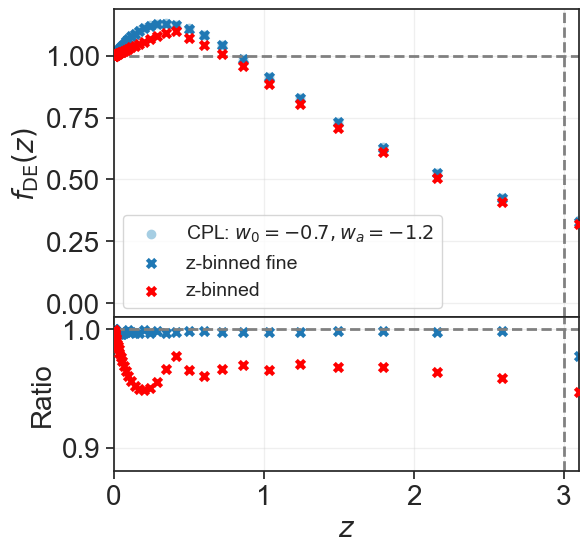

In [10]:
# plot f_de(z) from the three scenarios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})

# Top plot: absolute values
de_cpl = get_de_desnity_cpl(zs, w0, wa)
de_fine = get_de_density(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
de_binned = get_de_density(zs, zbin_edges, zbin_widths, zbin_centers, w_i)

de_fine_opt = get_de_density_opt(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
de_binned_opt = get_de_density_opt(zs, zbin_edges, zbin_widths, zbin_centers, w_i)


ax1.scatter(zs, de_cpl, label=f'CPL: $w_0={w0}, w_a={wa}$')
ax1.scatter(zs, de_fine, marker='x', label='z-binned fine')
ax1.scatter(zs, de_binned, label='z-binned', color='red', marker='x', zorder=10)

#ax1.scatter(zs, de_fine_opt, marker='x', label='z-binned fine')
#ax1.scatter(zs, de_binned_opt, label='z-binned', color='grey', marker='x', zorder=10)
#ax1.set_xscale('log')
ax1.axhline(y=1, c='grey', ls='--', lw=2)
ax1.axvline(x=zmax, c='grey', ls='--', lw=2)
ax1.set_ylabel(r'$f_{\rm DE}(z)$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom plot: ratios
ax2.scatter(zs, de_fine / de_cpl, marker='x', label='z-binned fine / CPL', color=colors[1])
ax2.scatter(zs, de_binned / de_cpl, label='z-binned / CPL', color='red', marker='x', zorder=10)
#ax2.set_xscale('log')
ax2.axhline(y=1, c='grey', ls='--', lw=2)
ax2.set_xlabel('$z$')
ax2.set_ylabel('Ratio')
#ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 3.1)
ax2.set_ylim(0.88, 1.01)
ax2.axvline(x=zmax, c='grey', ls='--', lw=2)
plt.show()

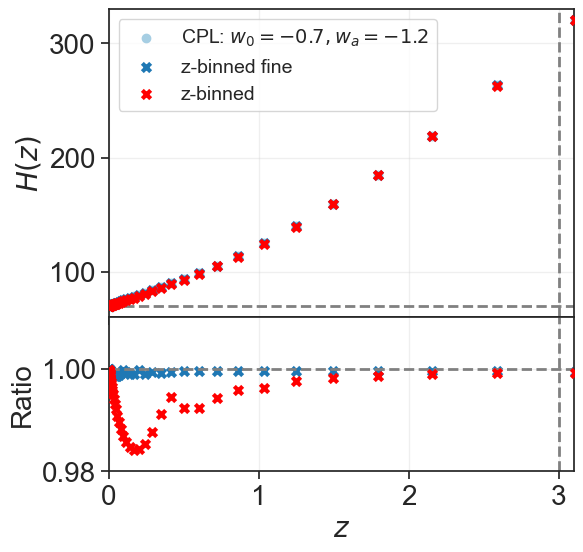

In [11]:
# plot H(z) from the three scenarios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0})

# Top plot: absolute values
de_cpl = get_de_desnity_cpl(zs, w0, wa)
de_fine = get_de_density(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
de_binned = get_de_density(zs, zbin_edges, zbin_widths, zbin_centers, w_i)

ax1.scatter(zs, hubble_cpl, label=f'CPL: $w_0={w0}, w_a={wa}$')
ax1.scatter(zs, H0*np.sqrt(de_fine*(1.-Omega_m)+Omega_m*(1.+zs)**3), marker='x', label='z-binned fine')
ax1.scatter(zs, H0*np.sqrt(de_binned*(1.-Omega_m)+Omega_m*(1.+zs)**3), label='z-binned', color='red', marker='x', zorder=10)
ax1.axhline(y=H0, c='grey', ls='--', lw=2)
ax1.axvline(x=zmax, c='grey', ls='--', lw=2)
ax1.set_ylabel('$H(z)$')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(60., 330)

# Bottom plot: ratios
ax2.scatter(zs, H0*np.sqrt(de_fine*(1.-Omega_m)+Omega_m*(1.+zs)**3) / hubble_cpl, marker='x', label='z-binned fine / CPL', color=colors[1])
ax2.scatter(zs, H0*np.sqrt(de_binned*(1.-Omega_m)+Omega_m*(1.+zs)**3) / hubble_cpl, label='z-binned / CPL', color='red', marker='x', zorder=10)
ax2.axhline(y=1, c='grey', ls='--', lw=2)
ax2.set_xlabel('$z$')
ax2.set_ylabel('Ratio')
#ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 3.1)
ax2.set_ylim(0.98, 1.01)
ax2.axvline(x=zmax, c='grey', ls='--', lw=2)
plt.show()

In [12]:
SPEED_OF_LIGHT = 2.99792458E8    
from quadax import quadgk
from scipy.integrate import quad
from jax import jit, vmap

# ============================================================================
# OPTIMIZED JAX FUNCTIONS - Key Performance Improvements:
# 1. Pre-compute cumulative products (O(1) lookup vs O(n) loop)
# 2. JIT-compile all functions for faster execution
# 3. Use vectorized operations where possible
# 4. Optional interpolation mode for even faster repeated calls
# ============================================================================

# JIT-compile get_z_bin_jax for better performance
@jit
def get_z_bin_jax_jit(z, zbin_edges):
    """JIT-compiled version of get_z_bin_jax."""
    z = jnp.asarray(z)
    zbin_edges = jnp.asarray(zbin_edges)
    bin_idx = jnp.searchsorted(zbin_edges, z, side='right') - 1
    bin_idx = jnp.clip(bin_idx, -1, len(zbin_edges) - 2)
    bin_idx = jnp.where(z >= zbin_edges[-1], len(zbin_edges) - 2, bin_idx)
    return bin_idx

@jit
def get_de_density_i_jax(z, zbin_edges, zbin_widths, zbin_centers, w_i, ratios_precomputed, cumprod_precomputed):
    """
    Optimized JAX version using pre-computed cumulative products.
    Much faster than using loops.
    """
    z = jnp.asarray(z)
    
    # Get bin index (using JIT-compiled version)
    bin_idx = get_z_bin_jax_jit(z, zbin_edges)
    
    # Use pre-computed cumulative products (O(1) lookup instead of O(n) loop)
    bin_idx_safe = jnp.maximum(0, bin_idx)
    bin_idx_safe = jnp.minimum(bin_idx_safe, len(zbin_centers) - 1)
    
    # Get product from pre-computed cumulative products
    product = cumprod_precomputed[bin_idx_safe]
    
    # Pre-computed denominator terms
    denom_terms = 1 + zbin_centers - zbin_widths/2
    
    # Compute final density
    rho = ((1+z) / denom_terms[bin_idx_safe])**(3.*(1.+w_i[bin_idx_safe])) * product
    return rho

def get_de_density_i_jax_wrapper(z, zbin_edges, zbin_widths, zbin_centers, w_i):
    """Wrapper that pre-computes ratios and cumulative products."""
    # Pre-compute ratios once (these don't depend on z)
    ratios = ((1+zbin_centers+(zbin_widths/2))/(1+zbin_centers-(zbin_widths/2)))**(3.*(1.+w_i))
    # Pre-compute cumulative products: cumprod[i] = product of ratios[0] * ... * ratios[i-1]
    cumprod = jnp.concatenate([jnp.array([1.0]), jnp.cumprod(ratios)])
    return get_de_density_i_jax(z, zbin_edges, zbin_widths, zbin_centers, w_i, ratios, cumprod)

@jit
def _integrand_jax(z, zbin_edges, zbin_widths, zbin_centers, w_i, ratios_precomputed, cumprod_precomputed):
    """JIT-compiled integrand for comoving distance."""
    de_density = get_de_density_i_jax(z, zbin_edges, zbin_widths, zbin_centers, w_i, ratios_precomputed, cumprod_precomputed)
    return 1./jnp.sqrt(Omega_m*jnp.power(1.+z, 3) + (1-Omega_m)*de_density)

def comoving_distance_jax(zz, zbin_edges, zbin_widths, zbin_centers, w_i, use_interp=False):
    """
    Optimized version with pre-computed values and better integration strategy.
    
    Parameters:
    -----------
    use_interp : bool
        If True, pre-compute density on a fine grid and use interpolation.
        Much faster for repeated calls with same binning parameters.
    """
    # Convert inputs to JAX arrays
    zbin_edges = jnp.asarray(zbin_edges)
    zbin_widths = jnp.asarray(zbin_widths)
    zbin_centers = jnp.asarray(zbin_centers)
    w_i = jnp.asarray(w_i)
    zz = jnp.asarray(zz)
    
    # Pre-compute ratios and cumulative products once (these don't depend on z)
    ratios = ((1+zbin_centers+(zbin_widths/2))/(1+zbin_centers-(zbin_widths/2)))**(3.*(1.+w_i))
    cumprod = jnp.concatenate([jnp.array([1.0]), jnp.cumprod(ratios)])
    
    if use_interp:
        # OPTION 1: Use interpolation for speed (best for repeated calls)
        # Pre-compute density on fine grid
        z_max = float(jnp.max(zz))
        z_fine = jnp.linspace(0, z_max*1.1, 1000)  # Fine grid
        de_fine = vmap(get_de_density_i_jax, in_axes=(0, None, None, None, None, None, None))(
            z_fine, zbin_edges, zbin_widths, zbin_centers, w_i, ratios, cumprod
        )
        
        # Create interpolated integrand
        def r_z_int_interp(z):
            # Interpolate density
            idx = jnp.searchsorted(z_fine, z)
            idx = jnp.clip(idx, 0, len(z_fine)-2)
            z0, z1 = z_fine[idx], z_fine[idx+1]
            de0, de1 = de_fine[idx], de_fine[idx+1]
            de = de0 + (de1 - de0) * (z - z0) / (z1 - z0)
            return 1./jnp.sqrt(Omega_m*jnp.power(1.+z, 3) + (1-Omega_m)*de)
        
        r_z_grid = jnp.array([quadgk(r_z_int_interp, [0, zz_i])[0]/H0 for zz_i in zz])*SPEED_OF_LIGHT/1000
    else:
        # OPTION 2: Direct integration (more accurate, slower)
        def r_z_int(z):
            return _integrand_jax(z, zbin_edges, zbin_widths, zbin_centers, w_i, ratios, cumprod)
        
        # Compute integral for each z value
        # Note: First call will be slower due to JIT compilation
        r_z_grid = jnp.array([quadgk(r_z_int, [0, zz_i])[0]/H0 for zz_i in zz])*SPEED_OF_LIGHT/1000 #Mpc
    
    return np.array(r_z_grid)  # Convert back to numpy for compatibility
    #r_z_grid = np.zeros(len(zz))
    #de = get_de_density(zz, zbin_edges, zbin_widths, zbin_centers, w_i)
    #hubble = H0*np.sqrt(de*(1.-Omega_m)+Omega_m*(1.+zz)**3)
    #for i in range(1, len(zz)):
    #    r_z_grid[i] = simpson(1./hubble[:i], zz[:i])
    #return r_z_grid*SPEED_OF_LIGHT/1000

In [13]:
# Note: The optimized versions are in Cell 12 above
# This cell is kept for reference or can be removed

In [14]:
comoving_distance_jax(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)

array([4.2812405e+00, 5.1392994e+00, 6.1692476e+00, 7.4054780e+00,
       8.8892488e+00, 1.0670049e+01, 1.2807224e+01, 1.5371925e+01,
       1.8449436e+01, 2.2141954e+01, 2.6571884e+01, 3.1885769e+01,
       3.8258976e+01, 4.5901203e+01, 5.5063007e+01, 6.6043510e+01,
       7.9199318e+01, 9.4955101e+01, 1.1381565e+02, 1.3637982e+02,
       1.6335632e+02, 1.9558147e+02, 2.3403851e+02, 2.7987857e+02,
       3.3444217e+02, 3.9928030e+02, 4.7621664e+02, 5.6739783e+02,
       6.7519287e+02, 8.0221667e+02, 9.5152563e+02, 1.1264515e+03,
       1.3304495e+03, 1.5672408e+03, 1.8403680e+03, 2.1528398e+03,
       2.5068469e+03, 2.9029343e+03, 3.3394346e+03, 3.8121104e+03,
       4.3145273e+03, 4.8382148e+03, 5.3744229e+03, 5.9135786e+03,
       6.4482896e+03, 6.9724624e+03, 7.4807012e+03, 7.9687808e+03,
       8.4339775e+03, 8.8749287e+03, 9.2897373e+03, 9.6785039e+03,
       1.0042068e+04, 1.0379627e+04, 1.0693527e+04, 1.0982885e+04,
       1.1251020e+04, 1.1497097e+04, 1.1724567e+04, 1.1933037e

In [15]:
SPEED_OF_LIGHT = 2.99792458E8    
from scipy.integrate import quad

def get_de_density_i(z, zbin_edges, zbin_widths, zbin_centers, w_i):
    bins = get_z_bin(z, zbin_edges)
    product = 1.
    #print('bins: ', bins)
    # Handle bins as scalar (get_z_bin returns scalar for scalar input)
    bin_idx = bins if isinstance(bins, (int, np.integer)) else bins[0]
    for j in range(bin_idx):
        #print('j: ', j)
        product *= ((1+zbin_centers[j]+(zbin_widths[j]/2))/(1+zbin_centers[j]-(zbin_widths[j]/2)))**(3.*(1.+w_i[j]))
    #print('product: ', product)
    rho = ( (1+z)/(1+zbin_centers[bin_idx]-zbin_widths[bin_idx]/2) )**(3.*(1.+w_i[bin_idx]))*product
    return rho


def comoving_distance(zz, zbin_edges, zbin_widths, zbin_centers, w_i):
    r_z_int = lambda z: 1./np.sqrt(Omega_m*pow(1.+z, 3) + (1-Omega_m)*get_de_density_i(z, zbin_edges, zbin_widths, zbin_centers, w_i))
    r_z_func = lambda z_in: quad(r_z_int, 0, z_in)[0]/H0
    r_z_grid = np.array([r_z_func(zz_i) for zz_i in zz])*SPEED_OF_LIGHT/1000 #Mpc
    return r_z_grid  
    #r_z_grid = np.zeros(len(zz))
    #de = get_de_density(zz, zbin_edges, zbin_widths, zbin_centers, w_i)
    #hubble = H0*np.sqrt(de*(1.-Omega_m)+Omega_m*(1.+zz)**3)
    #for i in range(1, len(zz)):
    #    r_z_grid[i] = simpson(1./hubble[:i], zz[:i])
    #return r_z_grid*SPEED_OF_LIGHT/1000    

In [16]:
zs_interp = np.hstack(([0.], np.logspace(-3, 3, 256)))
def comoving_distance_w_interp(zz, zbin_edges, zbin_widths, zbin_centers, w_i):
    fde_interp = interp1d(zs_interp, get_de_density(zs_interp, zbin_edges, zbin_widths, zbin_centers, w_i))
    r_z_int = lambda z: 1./np.sqrt(Omega_m*pow(1.+z, 3) + (1-Omega_m)*fde_interp(z))
    r_z_func = lambda z_in: quad(r_z_int, 0, z_in)[0]/H0
    r_z_grid = np.array([r_z_func(zz_i) for zz_i in zz])*SPEED_OF_LIGHT/1000 #Mpc
    return r_z_grid  

In [17]:
zs_interp = np.hstack(([0.], np.logspace(-3, 3, 256)))

def comoving_distance_optimized(zz, zbin_edges, zbin_widths, zbin_centers, w_i):
    r_z_int = lambda z: 1./np.sqrt(Omega_m*pow(1.+z, 3) + (1-Omega_m)*get_de_density_i(z, zbin_edges, zbin_widths, zbin_centers, w_i))
    #fde_interp = interp1d(zs_interp, get_de_density(zs_interp, zbin_edges, zbin_widths, zbin_centers, w_i))
    #r_z_int = lambda z: 1./np.sqrt(Omega_m*pow(1.+z, 3) + (1-Omega_m)*fde_interp(z))
    zz_ = np.hstack(([0.], zz))
    r_z_grid = np.array([quad(r_z_int, zz_[i], zz_[i+1])[0]/H0 for i in range(len(zz_)-1)])*SPEED_OF_LIGHT/1000 #Mpc
    r_z_total = np.cumsum(r_z_grid)
    #r_z_grid = np.array([r_z_func(zz_i) for zz_i in zz])*SPEED_OF_LIGHT/1000 #Mpc
    return r_z_total 

/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_4103/3049482544.py:20: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  r_z_func = lambda z_in: quad(r_z_int, 0, z_in)[0]/H0
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_4103/3049482544.py:20: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  r_z_func = lambda z_in: quad(r_z_int, 0, z_in)[0]/H0


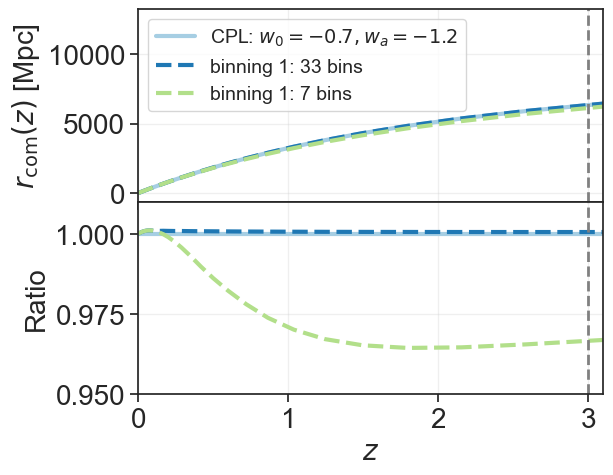

In [46]:
# plot r_com(z) from the three scenarios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), sharex=True, 
                                gridspec_kw={'height_ratios': [1, 1], 'hspace': 0})

# Top plot: absolute values
#ax1.scatter(zs, rcom_cpl, label=f'CPL: $w_0={w0}, w_a={wa}$')
#ax1.scatter(zs, comoving_distance(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine), marker='x', label='z-binned fine')
#ax1.scatter(zs, comoving_distance(zs, zbin_edges, zbin_widths, zbin_centers, w_i_fine), label='z-binned', color='red', marker='x', zorder=10)

ax1.plot(zs, rcom_cpl, label=f'CPL: $w_0={w0}, w_a={wa}$')
ax1.plot(zs, comoving_distance(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine),  label='binning 1: 33 bins', linestyle='--')
ax1.plot(zs, comoving_distance(zs, zbin_edges, zbin_widths, zbin_centers, w_i_fine), label='binning 1: 7 bins', linestyle='--')

#ax1.axhline(y=0., c='grey', ls='--', lw=2)
ax1.axvline(x=zmax, c='grey', ls='--', lw=2)
ax1.set_ylabel('$r_{\\rm com}(z)$ [Mpc]')
ax1.legend()
ax1.grid(True, alpha=0.3)
#ax1.set_ylim(60., 330)

# Bottom plot: ratios
#ax2.scatter(zs, comoving_distance(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine) / rcom_cpl, marker='x', label='z-binned fine / CPL', color=colors[1])
#ax2.scatter(zs, comoving_distance(zs, zbin_edges, zbin_widths, zbin_centers, w_i_fine) / rcom_cpl, label='z-binned / CPL', color='red', marker='x', zorder=10)
#ax2.scatter(zs, comoving_distance_optimized(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine) / rcom_cpl, marker='x', label='z-binned fine / CPL', color=colors[1])
#ax2.scatter(zs, comoving_distance_optimized(zs, zbin_edges, zbin_widths, zbin_centers, w_i_fine) / rcom_cpl, label='z-binned / CPL', color='red', marker='x', zorder=10)

ax2.plot(zs, rcom_cpl / rcom_cpl)
ax2.plot(zs, comoving_distance(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine) / rcom_cpl, linestyle='--')
ax2.plot(zs, comoving_distance(zs, zbin_edges, zbin_widths, zbin_centers, w_i_fine) / rcom_cpl, linestyle='--')


#ax2.axhline(y=1, c='grey', ls='--', lw=2)
ax2.set_xlabel('$z$')
ax2.set_ylabel('Ratio')
#ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 3.1)
ax2.set_ylim(0.95, 1.01)
ax2.axvline(x=zmax, c='grey', ls='--', lw=2)
plt.show()

In [19]:
def hubble_parameter(zs, zbin_edges, zbin_widths, zbin_centers, w_i, units: str = "km/s/Mpc") -> np.ndarray:
    DE_z_grid = get_de_density_opt(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
    E_z_grid = np.sqrt(Omega_m*pow(1.+zs, 3) + (1-Omega_m)*DE_z_grid)
    if units == "1/Mpc":
        return E_z_grid*H0/SPEED_OF_LIGHT/1000
    if units == "km/s/Mpc":
        return E_z_grid*H0
    raise ValueError("Unsupported units for hubble_parameter. Choose '1/Mpc' or 'km/s/Mpc'.")

from jax import jit, vmap, lax

def hubble_parameter_jax(zs, zbin_edges, zbin_widths, zbin_centers, w_i, units: str = "km/s/Mpc") -> np.ndarray:
    """
    Optimized JAX version using pre-computed cumulative products.
    """
    # Pre-compute ratios and cumulative products once
    zbin_centers = jnp.asarray(zbin_centers)
    zbin_widths = jnp.asarray(zbin_widths)
    w_i = jnp.asarray(w_i)
    
    ratios = ((1+zbin_centers+(zbin_widths/2))/(1+zbin_centers-(zbin_widths/2)))**(3.*(1.+w_i))
    cumprod = jnp.concatenate([jnp.array([1.0]), jnp.cumprod(ratios)])
    
    # Vectorize over zs using vmap with pre-computed values
    DE_z_grid = vmap(get_de_density_i_jax, in_axes=(0, None, None, None, None, None, None))(
        zs, zbin_edges, zbin_widths, zbin_centers, w_i, ratios, cumprod
    )
    E_z_grid = jnp.sqrt(Omega_m*jnp.power(1.+zs, 3) + (1-Omega_m)*DE_z_grid)
    if units == "1/Mpc":
        return np.array(E_z_grid*H0/SPEED_OF_LIGHT/1000)
    if units == "km/s/Mpc":
        return np.array(E_z_grid*H0)
    raise ValueError("Unsupported units for hubble_parameter. Choose '1/Mpc' or 'km/s/Mpc'.")

In [20]:
import time

In [21]:
start_time = time.time()
hubble_parameter(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
hubble_parameter_jax(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
hubble_parameter_jax(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")

Time taken: 0.0001819133758544922 seconds
Time taken: 0.23936986923217773 seconds
Time taken: 0.0008521080017089844 seconds


In [22]:
start_time = time.time()
hubble_parameter(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
hubble_parameter_jax(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
hubble_parameter_jax(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
print(f"Time taken: {time.time() - start_time} seconds")

Time taken: 0.00019693374633789062 seconds
Time taken: 0.0573880672454834 seconds
Time taken: 0.0009741783142089844 seconds


In [23]:
start_time = time.time()
comoving_distance(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
comoving_distance_jax(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
comoving_distance_jax(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
comoving_distance_jax(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine, use_interp=True)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
comoving_distance_jax(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine, use_interp=True)
print(f"Time taken: {time.time() - start_time} seconds")

/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_4103/3049482544.py:20: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  r_z_func = lambda z_in: quad(r_z_int, 0, z_in)[0]/H0
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_4103/3049482544.py:20: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  r_z_func = lambda z_in: quad(r_z_int, 0, z_in)[0]/H0


Time taken: 0.426347017288208 seconds
Time taken: 0.19179487228393555 seconds
Time taken: 0.19875597953796387 seconds
Time taken: 0.2636730670928955 seconds
Time taken: 0.19441604614257812 seconds


In [24]:
start_time = time.time()
comoving_distance(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
comoving_distance_jax(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
comoving_distance_jax(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")


start_time = time.time()
comoving_distance_jax(zs, zbin_edges, zbin_widths, zbin_centers, w_i, use_interp=True)
print(f"Time taken: {time.time() - start_time} seconds")

start_time = time.time()
comoving_distance_jax(zs, zbin_edges, zbin_widths, zbin_centers, w_i, use_interp=True)
print(f"Time taken: {time.time() - start_time} seconds")

Time taken: 0.18320083618164062 seconds
Time taken: 0.19904279708862305 seconds
Time taken: 0.20662307739257812 seconds
Time taken: 0.22902202606201172 seconds
Time taken: 0.19507408142089844 seconds


In [25]:
start_time = time.time()
background.comoving_distance(zs)
print(f"Time taken: {time.time() - start_time} seconds")

Time taken: 0.00026297569274902344 seconds


In [26]:
start_time = time.time()
comoving_distance_optimized(zs, zbin_fine_edges, zbin_fine_widths, zbin_fine_centers, w_i_fine)
print(f"Time taken: {time.time() - start_time} seconds")

Time taken: 0.03686094284057617 seconds


In [27]:
def get_de_density_opt_uni(z, zbin_edges, zbin_widths, zbin_centers, w_i):
    """
    Unified function that handles both scalar and array inputs for z.
    Uses optimized vectorization for arrays and efficient computation for scalars.
    
    Parameters:
    -----------
    z : float or array-like
        Redshift value(s) to compute dark energy density for
    zbin_edges : array-like
        Array of bin edges
    zbin_widths : array-like
        Array of bin widths
    zbin_centers : array-like
        Array of bin centers
    w_i : array-like
        Array of equation of state parameters for each bin
    
    Returns:
    --------
    rho : float or array
        Dark energy density. Returns scalar if z is scalar, array if z is array.
    """
    # Check if input is scalar
    is_scalar = np.isscalar(z)



    # Handle both scalar and array cases
    if is_scalar:
        bins = get_z_bin(z, zbin_edges)
        product = 1.
        # Scalar case: use direct indexing (faster for single value)
        bin_idx = bins if isinstance(bins, (int, np.integer)) else bins[0]
        bin_idx_safe = max(0, bin_idx)
        #product = cumprod[bin_idx_safe]
        #rho = ((1+z) / denom_terms[bin_idx_safe])**(3.*(1.+w_i[bin_idx_safe])) * product
        #print('rho no-loop: ', rho)
        #product = 1.
        for j in range(bin_idx):
            product *= ((1+zbin_centers[j]+(zbin_widths[j]/2))/(1+zbin_centers[j]-(zbin_widths[j]/2)))**(3.*(1.+w_i[j]))
        rho = ( (1+z)/(1+zbin_centers[bin_idx]-zbin_widths[bin_idx]/2) )**(3.*(1.+w_i[bin_idx]))*product
        #print('rho loop: ', rho)
        return float(rho)  # Return scalar
    else:
        # Convert to array for processing (works for both scalar and array)
        z = np.asarray(z)
        bins = get_z_bin(z, zbin_edges)
        # Pre-compute denominator terms for all bins
        denom_terms = 1+zbin_centers - zbin_widths/2
        # Pre-compute ratio terms for all bins (vectorized, done once)
        # These don't depend on z, so compute once and reuse
        ratios = ((1+zbin_centers+(zbin_widths/2))/(1+zbin_centers-(zbin_widths/2)))**(3.*(1.+w_i))
        # Pre-compute cumulative products for all possible bin ranges
        # cumprod[i] = product of ratios[0] * ratios[1] * ... * ratios[i-1]
        cumprod = np.concatenate([[1.0], np.cumprod(ratios)])

        # Array case: use vectorized operations
        bin_idx_safe = np.maximum(0, bins)
        products = cumprod[bin_idx_safe]
        rho = ((1+z) / denom_terms[bin_idx_safe])**(3.*(1.+w_i[bin_idx_safe])) * products
        return rho  # Return array

In [28]:
def hubble_parameter_opt_uni(zs, zbin_edges, zbin_widths, zbin_centers, w_i, units: str = "km/s/Mpc") -> np.ndarray:
    DE_z_grid = get_de_density_opt(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
    E_z_grid = np.sqrt(Omega_m*pow(1.+zs, 3) + (1-Omega_m)*DE_z_grid)
    if units == "1/Mpc":
        return E_z_grid*H0/SPEED_OF_LIGHT/1000
    if units == "km/s/Mpc":
        return E_z_grid*H0
    raise ValueError("Unsupported units for hubble_parameter. Choose '1/Mpc' or 'km/s/Mpc'.")

In [29]:
def comoving_distance_opt_uni(zz, zbin_edges, zbin_widths, zbin_centers, w_i):
    r_z_int = lambda z: 1./np.sqrt(Omega_m*pow(1.+z, 3) + (1-Omega_m)*get_de_density_i(z, zbin_edges, zbin_widths, zbin_centers, w_i))
    zz_ = np.hstack(([0.], zz))
    r_z_grid = np.array([quad(r_z_int, zz_[i], zz_[i+1])[0]/H0 for i in range(len(zz_)-1)])*SPEED_OF_LIGHT/1000 #Mpc
    r_z_total = np.cumsum(r_z_grid)
    return r_z_total 

In [30]:
start_time = time.time()
hubble_parameter_opt_uni(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")
start_time = time.time()
comoving_distance_opt_uni(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")


Time taken: 0.000186920166015625 seconds
Time taken: 0.02198481559753418 seconds


In [31]:
@jit
def get_z_bin_jax_jit(z, zbin_edges):
    """JIT-compiled version of get_z_bin_jax."""
    z = jnp.asarray(z)
    zbin_edges = jnp.asarray(zbin_edges)
    bin_idx = jnp.searchsorted(zbin_edges, z, side='right') - 1
    bin_idx = jnp.clip(bin_idx, -1, len(zbin_edges) - 2)
    bin_idx = jnp.where(z >= zbin_edges[-1], len(zbin_edges) - 2, bin_idx)
    return bin_idx

@jit
def get_de_density_i_jax(z, zbin_edges, zbin_widths, zbin_centers, w_i, ratios_precomputed, cumprod_precomputed):
    """
    Optimized JAX version using pre-computed cumulative products.
    Much faster than using loops.
    """
    z = jnp.asarray(z)
    
    # Get bin index (using JIT-compiled version)
    bin_idx = get_z_bin_jax_jit(z, zbin_edges)
    
    # Use pre-computed cumulative products (O(1) lookup instead of O(n) loop)
    bin_idx_safe = jnp.maximum(0, bin_idx)
    bin_idx_safe = jnp.minimum(bin_idx_safe, len(zbin_centers) - 1)
    
    # Get product from pre-computed cumulative products
    product = cumprod_precomputed[bin_idx_safe]
    
    # Pre-computed denominator terms
    denom_terms = 1 + zbin_centers - zbin_widths/2
    
    # Compute final density
    rho = ((1+z) / denom_terms[bin_idx_safe])**(3.*(1.+w_i[bin_idx_safe])) * product
    return rho


@jit
def _integrand_jax(z, zbin_edges, zbin_widths, zbin_centers, w_i, ratios_precomputed, cumprod_precomputed):
    """JIT-compiled integrand for comoving distance."""
    de_density = get_de_density_i_jax(z, zbin_edges, zbin_widths, zbin_centers, w_i, ratios_precomputed, cumprod_precomputed)
    return 1./jnp.sqrt(Omega_m*jnp.power(1.+z, 3) + (1-Omega_m)*de_density)

def comoving_distance_jax(zz, zbin_edges, zbin_widths, zbin_centers, w_i, use_interp=False):
    """
    Optimized version with pre-computed values and better integration strategy.
    
    Parameters:
    -----------
    use_interp : bool
        If True, pre-compute density on a fine grid and use interpolation.
        Much faster for repeated calls with same binning parameters.
    """
    # Convert inputs to JAX arrays
    zbin_edges = jnp.asarray(zbin_edges)
    zbin_widths = jnp.asarray(zbin_widths)
    zbin_centers = jnp.asarray(zbin_centers)
    w_i = jnp.asarray(w_i)
    zz_ = jnp.asarray(np.hstack(([0.], zz)))
    
    # Pre-compute ratios and cumulative products once (these don't depend on z)
    ratios = ((1+zbin_centers+(zbin_widths/2))/(1+zbin_centers-(zbin_widths/2)))**(3.*(1.+w_i))
    cumprod = jnp.concatenate([jnp.array([1.0]), jnp.cumprod(ratios)])
    

    def r_z_int(z):
        return _integrand_jax(z, zbin_edges, zbin_widths, zbin_centers, w_i, ratios, cumprod)
    
    # Compute integral for each z value
    # Note: First call will be slower due to JIT compilation
    r_z_grid = jnp.array([quadgk(r_z_int, [zz_[i], zz_[i+1]])[0]/H0 for i in range(len(zz_))])*SPEED_OF_LIGHT/1000 #Mpc
    
    return np.array(r_z_grid)  # Convert back to numpy for compatibility

In [32]:
start_time = time.time()
comoving_distance_jax(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")
start_time = time.time()
comoving_distance_jax(zs, zbin_edges, zbin_widths, zbin_centers, w_i)
print(f"Time taken: {time.time() - start_time} seconds")

Time taken: 0.3180050849914551 seconds
Time taken: 0.19897699356079102 seconds


In [33]:
import HMcode2020Emu as hmcodeemu
HM2020_emu = hmcodeemu.Matter_powerspectrum()        
hm_bounds = HM2020_emu.emulator['nonlinear']['bounds']        

Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...


Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [34]:
params_hm_emu = {
            'omega_cdm': 0.2,
            'omega_baryon': 0.05,
            # modify for pseudo-power spectrum
            'As': [2.e-9, 2.e-9, 2.e-9], 
            'ns': 0.97,
            'hubble': 0.68,
            'neutrino_mass': 0.,
            'w0': -1.,
            'wa': 0.,
        }
for key in params_hm_emu.keys():
    if key != 'As':
        if np.prod(params_hm_emu[key] - hm_bounds[key]) > 0:
            raise ValueError("HMcode 2020 NL emulator out of range.")
    else:
        check = np.array([np.prod(As_i - hm_bounds['As']) for As_i in params_hm_emu['As']])
        if (check > 0).any():
            raise ValueError("lol.")
